## Fundamentos: Limpeza de Dados

Usando o dataset do Titanic desta [competição](https://www.kaggle.com/c/titanic/overview) do Kaggle.

Este dataset contém informações sobre 891 pessoas que estavam a bordo do Titanic quando ele partiu em 15 de abril de 1912. Como observado na descrição do Kaggle, algumas pessoas a bordo tinham mais chances de sobreviver ao naufrágio do que outras: não havia botes salva-vidas suficientes para todos, então mulheres, crianças e passageiros de classes mais altas foram priorizados. Usando as informações sobre esses 891 passageiros, o desafio é construir um modelo que preveja quem sobrevive, com base nos seguintes campos:

- **Name** (str) - Nome do passageiro
- **Pclass** (int) - Classe da passagem (1 = 1ª, 2 = 2ª, 3 = 3ª)
- **Sex** (str) - Sexo do passageiro
- **Age** (float) - Idade em anos
- **SibSp** (int) - Número de irmãos e cônjuges a bordo
- **Parch** (int) - Número de pais e filhos a bordo
- **Ticket** (str) - Número do bilhete
- **Fare** (float) - Tarifa paga pelo passageiro
- **Cabin** (str) - Número da cabine
- **Embarked** (str) - Porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)

**Por que limpar os dados primeiro?** Algoritmos de machine learning geralmente esperam uma tabela de números sem valores ausentes. Os dados brutos acima têm alguns problemas que impedem isso:

1. Alguns campos têm valores ausentes (`Age`, `Cabin`, `Embarked`)
2. Alguns campos são texto em vez de números (`Sex`, `Name`, `Ticket`, `Cabin`, `Embarked`)
3. Alguns campos, isoladamente, não são muito informativos, mas podem ser transformados em algo que seja (ex.: `SibSp` + `Parch` descrevem o tamanho da família)
4. Ainda não verificamos o arquivo quanto a problemas estruturais (delimitador errado, cabeçalho quebrado) ou rótulos inconsistentes (erros de digitação, capitalização mista, espaços em branco)

Ao final deste notebook, teremos inspecionado o arquivo bruto, explorado os dados, resolvido cada um desses problemas e salvo um dataset totalmente numérico e pronto para modelagem em `titanic_cleaned.csv`.

### 1. Carregar e inspecionar o arquivo bruto

Antes de confiar que o pandas vai interpretar o arquivo corretamente, vale a pena olhar primeiro o texto bruto: qual delimitador é usado, se existe uma linha de cabeçalho e se todas as linhas têm o mesmo número de campos. Pular essa etapa é como se acaba depurando uma coluna "ausente" uma hora depois, quando o problema real era um arquivo delimitado por ponto e vírgula sendo lido como se fosse delimitado por vírgula.

In [1]:
with open('titanic.csv', encoding='utf-8') as f:
    first_lines = [next(f) for _ in range(10)]

for line in first_lines:
    print(line)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked

1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S

2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C

3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S

4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S

5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S

6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q

7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S

8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S

9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S



A primeira linha é o cabeçalho, e os campos são separados por vírgulas — um CSV padrão e bem formado. Cada linha de dados tem o mesmo número de campos separados por vírgula que o cabeçalho, o que é um bom indício inicial de que o arquivo não está corrompido nem misturando delimitadores. Agora vamos carregá-lo com o pandas.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='colorblind')
SURVIVED_COLORS = {0: sns.color_palette('colorblind')[1], 1: sns.color_palette('colorblind')[0]}

titanic = pd.read_csv('titanic.csv', sep=',')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Verificar problemas estruturais e de consistência

Antes de mergulhar nos valores ausentes, vale a pena verificar os tipos de problema que nem sempre aparecem no `.head()`: linhas duplicadas e campos categóricos com rótulos inconsistentes (espaços extras, capitalização mista, erros de digitação, códigos inesperados).

In [3]:
print('Linhas duplicadas:', titanic.duplicated().sum())
print()
print('Valores de Pclass:', sorted(titanic['Pclass'].unique()))
print('Valores de Sex:', titanic['Sex'].unique())
print('Valores de Embarked:', titanic['Embarked'].unique())

Linhas duplicadas: 0

Valores de Pclass: [np.int64(1), np.int64(2), np.int64(3)]
Valores de Sex: <ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
Valores de Embarked: <ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


Não há linhas duplicadas, e os campos categóricos (`Pclass`, `Sex`, `Embarked`) contêm apenas os valores esperados — sem espaços em branco perdidos, capitalização inconsistente ou códigos inesperados. Isso nem sempre é o caso em dados do mundo real, mas significa que podemos pular uma etapa separada de "corrigir rótulos inconsistentes" aqui. `Embarked`, porém, aparece como `nan` em duas linhas, o que trataremos mais adiante.

### 3. Explorar os dados

Agora que confiamos na estrutura do arquivo, vamos entender o formato dos dados, os tipos de cada campo e quais campos têm valores ausentes ou incomuns.

In [4]:
print(f'Linhas: {titanic.shape[0]}, Colunas: {titanic.shape[1]}')
titanic.info()

Linhas: 891, Colunas: 12
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


`Age`, `Cabin` e `Embarked` mostram menos valores não nulos do que as outras 891 linhas — esses são nossos três campos com dados ausentes. `Name`, `Sex`, `Ticket`, `Cabin` e `Embarked` são armazenados como texto (`object`), que a maioria dos algoritmos de machine learning não consegue usar diretamente, então precisaremos convertê-los ou descartá-los.

In [5]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


As estatísticas resumo apontam para algo que vale a pena investigar: `Fare` varia de gratuito (0) até mais de 512, então um pequeno número de passageiros muito ricos vai aparecer como outliers, e devemos ter cuidado ao confiar na média em qualquer lugar onde ela possa ser distorcida por eles.

In [6]:
titanic['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Apenas cerca de 38% dos passageiros sobreviveram no total. Vamos verificar se a sobrevivência realmente dependeu de `Sex` e `Pclass` tão fortemente quanto sugere o registro histórico, e se `Age` e `Fare` também mostram algum padrão.

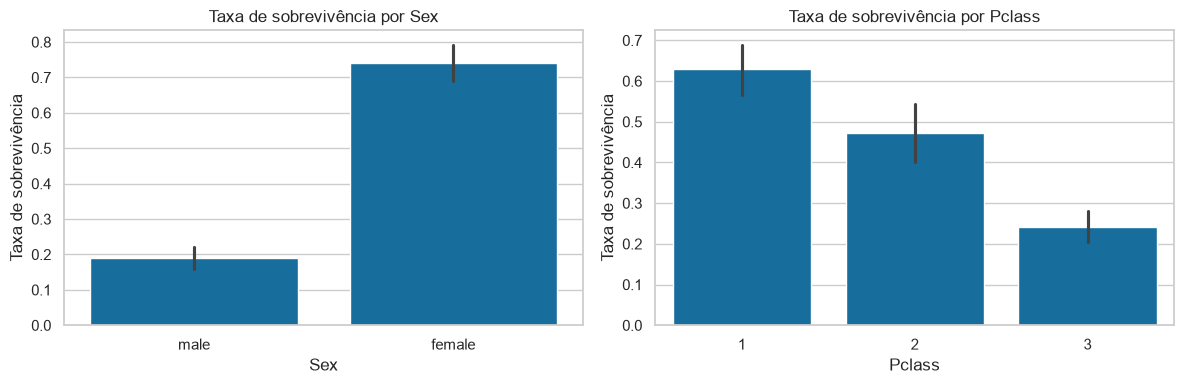

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x='Sex', y='Survived', data=titanic, ax=axes[0])
axes[0].set_title('Taxa de sobrevivência por Sex')
axes[0].set_ylabel('Taxa de sobrevivência')

sns.barplot(x='Pclass', y='Survived', data=titanic, ax=axes[1])
axes[1].set_title('Taxa de sobrevivência por Pclass')
axes[1].set_ylabel('Taxa de sobrevivência')

plt.tight_layout()
plt.show()

Os dois gráficos confirmam o relato histórico: mulheres sobreviveram a uma taxa muito maior que os homens, e passageiros da 1ª classe sobreviveram a uma taxa muito maior que os da 3ª classe. `Sex` e `Pclass` parecem ser fortes preditores, o que reforça que vale a pena colocar o restante dos dados em boa forma para um modelo.

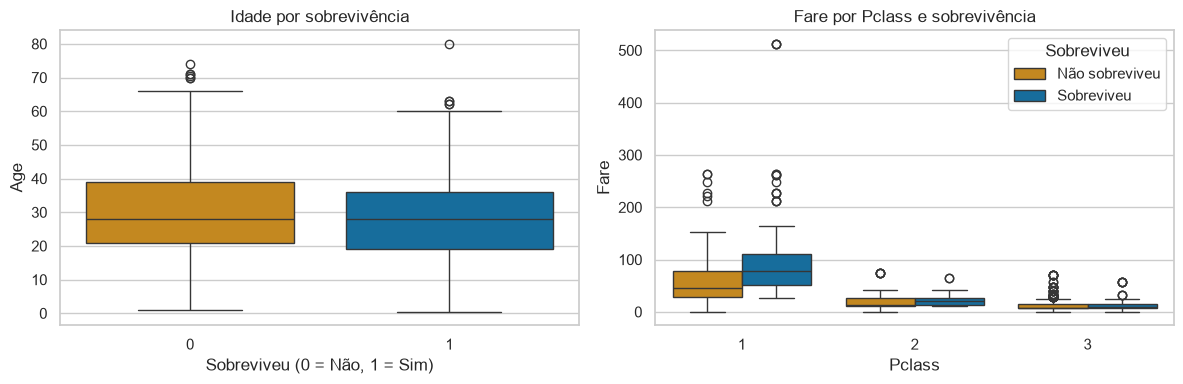

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Survived', y='Age', hue='Survived', data=titanic, palette=SURVIVED_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Idade por sobrevivência')
axes[0].set_xlabel('Sobreviveu (0 = Não, 1 = Sim)')
axes[0].set_ylabel('Age')

sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=titanic, palette=SURVIVED_COLORS, ax=axes[1])
axes[1].set_title('Fare por Pclass e sobrevivência')
axes[1].set_ylabel('Fare')
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Não sobreviveu', 'Sobreviveu'], title='Sobreviveu')

plt.tight_layout()
plt.show()

`Age` não separa sobreviventes de não sobreviventes de forma tão nítida quanto `Sex` ou `Pclass` — as caixas se sobrepõem bastante. `Fare` conta uma história multivariada mais rica: dentro de cada classe, os sobreviventes tenderam a pagar uma tarifa um pouco mais alta, e as tarifas da 1ª classe (e sua dispersão) ofuscam as das outras duas classes. Isso é um bom lembrete de que uma única variável raramente conta a história toda — é a combinação de atributos que um modelo acaba aprendendo.

### Outras visualizações exploratórias

Além de `Sex`, `Pclass`, `Age` e `Fare`, vale explorar mais algumas relações antes de seguir para a limpeza: `Embarked` isoladamente, a distribuição completa de `Age` e `Fare` (não apenas seus quartis) e o efeito combinado de `Pclass` e `Sex`.

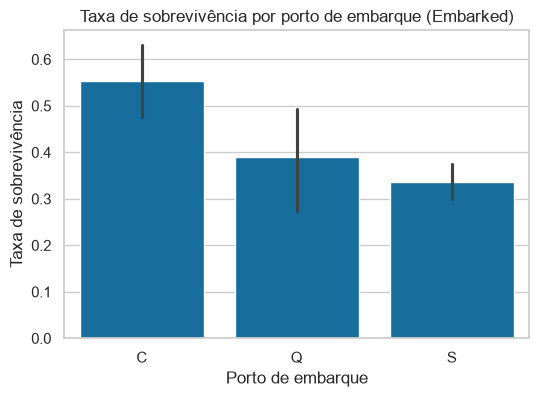

In [9]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(x='Embarked', y='Survived', data=titanic, order=['C', 'Q', 'S'])
ax.set_title('Taxa de sobrevivência por porto de embarque (Embarked)')
ax.set_xlabel('Porto de embarque')
ax.set_ylabel('Taxa de sobrevivência')
plt.show()

Quem embarcou em Cherbourg (`C`) sobreviveu a uma taxa bem maior (55%) do que quem embarcou em Queenstown (`Q`, 39%) ou Southampton (`S`, 34%). Isso provavelmente não é um efeito do porto em si: cerca de metade dos passageiros de Cherbourg viajava na 1ª classe, contra praticamente ninguém em Queenstown — então `Embarked` está, em parte, capturando o mesmo sinal que `Pclass`.

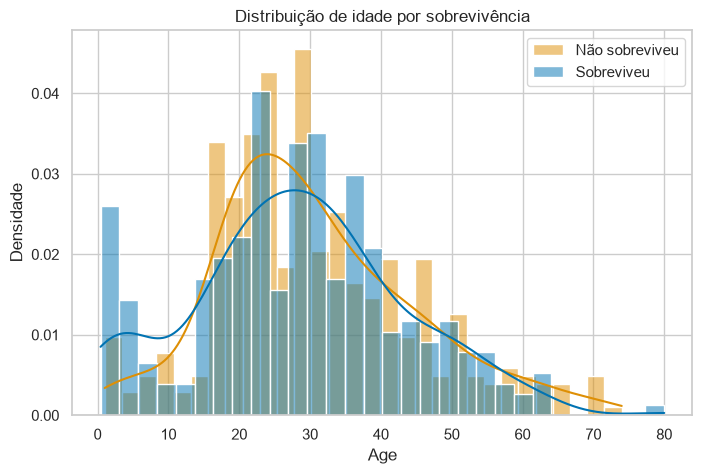

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(titanic.loc[titanic['Survived'] == 0, 'Age'], bins=30, kde=True, stat='density',
             color=SURVIVED_COLORS[0], label='Não sobreviveu', alpha=0.5)
sns.histplot(titanic.loc[titanic['Survived'] == 1, 'Age'], bins=30, kde=True, stat='density',
             color=SURVIVED_COLORS[1], label='Sobreviveu', alpha=0.5)
plt.title('Distribuição de idade por sobrevivência')
plt.xlabel('Age')
plt.ylabel('Densidade')
plt.legend()
plt.show()

As distribuições de idade de sobreviventes e não sobreviventes se sobrepõem bastante, confirmando o que o boxplot já sugeria. Mas olhando mais de perto, um grupo se destaca: crianças até 12 anos sobreviveram a uma taxa de 58%, a maior de qualquer faixa etária, enquanto passageiros com 60 anos ou mais sobreviveram a apenas 23%, a menor. `Age` sozinha não separa bem as duas classes, mas carrega um sinal real nas pontas da distribuição.

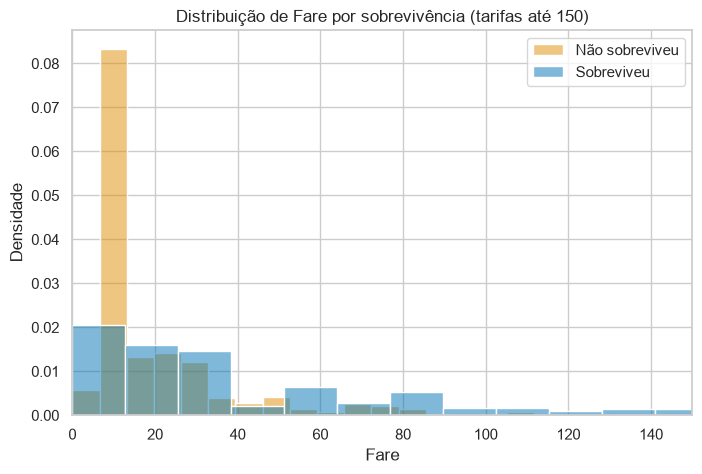

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(titanic.loc[titanic['Survived'] == 0, 'Fare'], bins=40, stat='density',
             color=SURVIVED_COLORS[0], label='Não sobreviveu', alpha=0.5)
sns.histplot(titanic.loc[titanic['Survived'] == 1, 'Fare'], bins=40, stat='density',
             color=SURVIVED_COLORS[1], label='Sobreviveu', alpha=0.5)
plt.xlim(0, 150)
plt.title('Distribuição de Fare por sobrevivência (tarifas até 150)')
plt.xlabel('Fare')
plt.ylabel('Densidade')
plt.legend()
plt.show()

Sobreviventes se concentram menos nas tarifas mais baixas e têm uma cauda mais longa em tarifas altas — a tarifa média de quem sobreviveu (48) foi mais que o dobro da de quem não sobreviveu (22), na mesma direção do que já tínhamos visto por `Pclass`. Como poucos passageiros pagaram tarifas muito altas (até 512), limitamos o eixo a 150 para deixar a maior parte da distribuição visível.

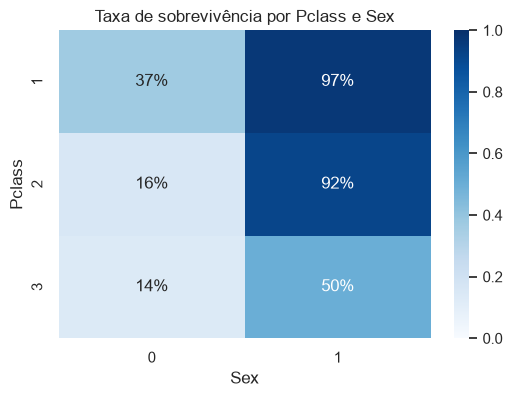

In [35]:
pivot = titanic.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1)
plt.title('Taxa de sobrevivência por Pclass e Sex')
plt.show()

Combinar `Pclass` e `Sex` mostra o quanto os dois efeitos se somam: mulheres da 1ª e 2ª classe sobreviveram a taxas acima de 90%, enquanto homens da 3ª classe sobreviveram a apenas 14%. Mesmo dentro da 3ª classe, ser mulher ainda multiplicava a chance de sobrevivência por quase quatro em relação a ser homem (50% vs 14%) — reforçando por que `Sex` e `Pclass` devem entrar juntos no modelo.

Essas visualizações reforçam o que já esperávamos: `Sex` e `Pclass` (isolados ou combinados) são os sinais mais fortes, `Fare` carrega parte do mesmo sinal de forma contínua, `Embarked` provavelmente está de olho em `Pclass`, e `Age` só ajuda nas pontas da distribuição. Com essa visão mais completa dos dados, vamos seguir para a limpeza.

### 4. Limpar variáveis contínuas

Vamos começar com os dois campos numéricos que precisam de ajuste: `Age` (valores ausentes) e `SibSp`/`Parch` (melhor combinados em um único atributo).

#### Preencher valores ausentes de `Age`

In [36]:
titanic.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Family_cnt    0
Cabin_ind     0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

`Age` está ausente para 177 passageiros (cerca de 20% dos dados) — descartar essas linhas jogaria fora muito sinal dos outros campos. Em vez disso, vamos preencher com um único valor representativo. Como estamos escolhendo um número para representar a idade "típica" do passageiro, vale comparar as três medidas de tendência central mais comuns antes de escolher uma:

In [37]:
age_mean = titanic['Age'].mean()
age_median = titanic['Age'].median()
age_mode = titanic['Age'].mode()[0]
age_skew = titanic['Age'].skew()

print(f'Média:      {age_mean:.2f}')
print(f'Mediana:    {age_median:.2f}')
print(f'Moda:       {age_mode:.2f}')
print(f'Assimetria: {age_skew:.2f}')

Média:      29.70
Mediana:    29.70
Moda:       29.70
Assimetria: 0.43


A média e a mediana estão bem próximas, com apenas uma pequena assimetria positiva — uma cauda um pouco mais longa de passageiros mais velhos puxando a média alguns anos acima da mediana. Isso não é extremo o suficiente para nos preocuparmos com outliers distorcendo a média, então vamos usá-la. (Se a diferença fosse bem maior, a mediana costuma ser a escolha mais segura, por ser menos sensível a outliers; a moda costuma ser mais útil para campos categóricos do que para um campo contínuo como `Age`.) Veja como fica a distribuição antes de preenchermos qualquer coisa:

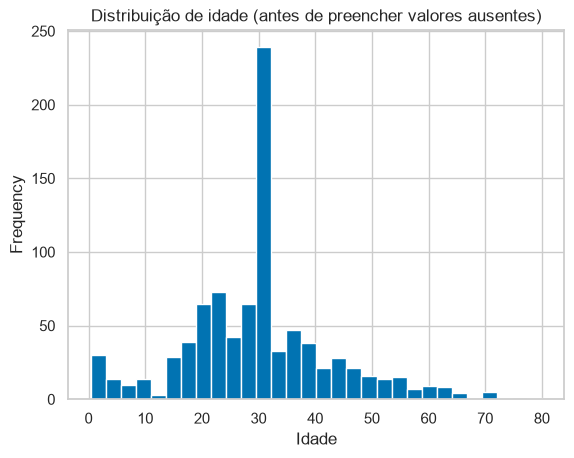

In [38]:
titanic['Age'].plot(kind='hist', bins=30, title='Distribuição de idade (antes de preencher valores ausentes)')
plt.xlabel('Idade')
plt.show()

In [39]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
titanic.head(10)
titanic.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Family_cnt    0
Cabin_ind     0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

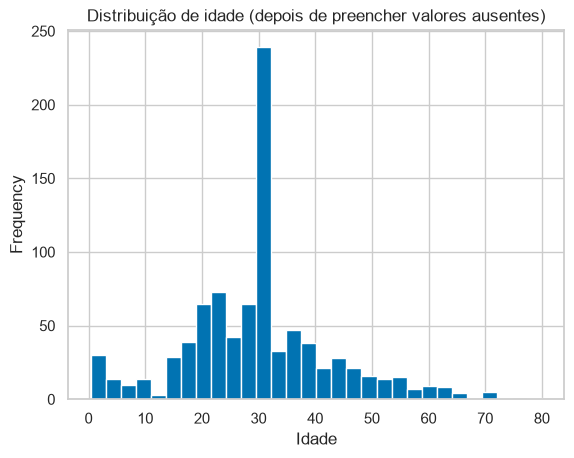

In [40]:
titanic['Age'].plot(kind='hist', bins=30, title='Distribuição de idade (depois de preencher valores ausentes)')
plt.xlabel('Idade')
plt.show()

Preencher com a média puxa levemente o pico da distribuição e suaviza um pouco sua dispersão, mas mantém o formato geral intacto — uma troca aceitável considerando o ganho em ter os dados prontos para modelagem, e `Age` não tem mais nenhum valor ausente.

#### Combinar `SibSp` e `Parch`

`SibSp` (irmãos/cônjuges a bordo) e `Parch` (pais/filhos a bordo) descrevem relações familiares. Em vez de alimentar o modelo com duas contagens separadas e esparsas, vamos verificar se elas se relacionam com a sobrevivência de forma parecida, e se faz sentido combiná-las em um único atributo de tamanho de família.

In [41]:
for col in ['SibSp', 'Parch']:
    g = sns.catplot(x=col, y='Survived', data=titanic, kind='point', aspect=2)
    g.fig.suptitle(f'Taxa de sobrevivência por {col}', y=1.05)
    g.set_axis_labels(col, 'Taxa de sobrevivência')
plt.show()

ValueError: Could not interpret value `SibSp` for `x`. An entry with this name does not appear in `data`.

Tanto `SibSp` quanto `Parch` mostram um padrão parecido: a sobrevivência é menor para quem viajava completamente sozinho (0), sobe para famílias pequenas, e cai novamente para famílias muito grandes. Essa semelhança é exatamente o motivo pelo qual combiná-los em um único atributo `Family_cnt` faz sentido — ele deve capturar o padrão sem ensinar ao modelo dois campos quase idênticos.

In [ ]:
titanic['Family_cnt'] = titanic['SibSp'] + titanic['Parch']
print (titanic['Family_cnt'])

In [ ]:
g = sns.catplot(x='Family_cnt', y='Survived', data=titanic, kind='point', aspect=2)
g.fig.suptitle('Taxa de sobrevivência por Family_cnt', y=1.05)
g.set_axis_labels('Family_cnt', 'Taxa de sobrevivência')
plt.show()

O atributo combinado reproduz o mesmo padrão que vimos para `SibSp` e `Parch` individualmente — essa é a versão que vamos manter e levar adiante.

#### Descartar variáveis desnecessárias

Agora que `Family_cnt` captura o que precisamos, as colunas originais `SibSp` e `Parch` ficam redundantes, e `PassengerId` é apenas um identificador de linha sem valor preditivo — então vamos descartar as três.

In [21]:
titanic.drop(['PassengerId', 'SibSp', 'Parch'], axis=1, inplace=True)

In [22]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,Family_cnt
0,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,S,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,S,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,1
4,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,S,0


### Limpar variáveis categóricas

Agora vamos tratar os campos de texto: `Cabin`, `Embarked`, `Sex`, `Ticket` e `Name`. Vamos transformar o que der em sinal numérico — usando uma técnica de transformação diferente dependendo do tipo de categoria de cada campo — e descartar o que sobrar.

#### Preencher ausentes e criar indicador para `Cabin`

In [23]:
titanic.isnull().sum()

Survived        0
Pclass          0
Name            0
Sex             0
Age             0
Ticket          0
Fare            0
Cabin         687
Embarked        2
Family_cnt      0
dtype: int64

`Cabin` está ausente para 687 dos 891 passageiros (77%) — muitos demais para preencher com confiança. Mas talvez apenas saber *se* um passageiro tinha uma cabine registrada já seja informativo por si só (números de cabine podem ter sido registrados só para certas classes, ou recuperados com mais frequência para sobreviventes). Vamos verificar.

In [24]:
titanic.groupby(titanic['Cabin'].isnull())['Survived'].mean()

Cabin
False    0.666667
True     0.299854
Name: Survived, dtype: float64

Essa é uma diferença grande: passageiros com cabine registrada sobreviveram a uma taxa mais que o dobro da de quem não tinha. Em vez de tentar adivinhar 687 números de cabine ausentes, vamos capturar esse sinal com um indicador simples 0/1, `Cabin_ind`.

In [25]:
titanic['Cabin_ind'] = np.where(titanic['Cabin'].isnull(), 0, 1)
titanic.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,Family_cnt,Cabin_ind
0,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,S,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,C,1,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,S,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,S,1,1
4,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,S,0,0


#### Preencher ausentes e codificar `Embarked`

`Embarked` está ausente para apenas 2 passageiros, então, diferente de `Age` ou `Cabin`, não é necessário descartar a coluna inteira — basta preencher essas duas linhas. `Embarked` é categórico, não numérico, então "tendência central" aqui significa a **moda**: o porto que aparece com mais frequência.

In [26]:
titanic['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Southampton (`S`) é de longe o porto mais comum, então vamos preencher os dois valores ausentes com ele.

In [27]:
embarked_mode = titanic['Embarked'].mode()[0]
titanic['Embarked'] = titanic['Embarked'].fillna(embarked_mode)
titanic['Embarked'].isnull().sum()

np.int64(0)

`Embarked` não tem uma ordem natural — Cherbourg não é "mais" ou "menos" que Southampton — então mapeá-lo para 0/1/2 do jeito que faremos com `Sex` implicaria erroneamente uma hierarquia. Em vez disso, vamos usar **one-hot encoding**: transformar a única coluna em uma coluna indicadora 0/1 para cada porto.

In [28]:
titanic = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked', dtype=int)
titanic.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Family_cnt,Cabin_ind,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,NaN,1,0,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C85,1,1,1,0,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,NaN,0,0,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,C123,1,1,0,0,1
4,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,NaN,0,0,0,0,1


`pd.get_dummies` substituiu a única coluna `Embarked` pelas colunas indicadoras `Embarked_C`, `Embarked_Q` e `Embarked_S` — exatamente uma delas é `1` para cada passageiro.

#### Converter `Sex` para numérico

Agora que já capturamos o que precisávamos de `Cabin` (o indicador) e `Embarked` (as colunas one-hot), podemos descartar as colunas que não vamos usar diretamente: o próprio `Cabin`, `Name` e `Ticket` (texto livre sem significado numérico direto).

In [29]:
titanic.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)
titanic.head()

,Survived,Pclass,Sex,Age,Fare,Family_cnt,Cabin_ind,Embarked_C,Embarked_Q,Embarked_S
0,0,3,male,22.0,7.2500,1,0,0,0,1
1,1,1,female,38.0,71.2833,1,1,1,0,0
2,1,3,female,26.0,7.9250,0,0,0,0,1
3,1,1,female,35.0,53.1000,1,1,0,0,1
4,0,3,male,35.0,8.0500,0,0,0,0,1


In [30]:
gender_num = {'male': 0, 'female': 1}

titanic['Sex'] = titanic['Sex'].map(gender_num)
titanic.head()

,Survived,Pclass,Sex,Age,Fare,Family_cnt,Cabin_ind,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,7.2500,1,0,0,0,1
1,1,1,1,38.0,71.2833,1,1,1,0,0
2,1,3,1,26.0,7.9250,0,0,0,0,1
3,1,1,1,35.0,53.1000,1,1,0,0,1
4,0,3,0,35.0,8.0500,0,0,0,0,1


Diferente de `Embarked`, `Sex` tem apenas duas categorias e nenhum problema de hierarquia com um mapeamento 0/1, então um mapeamento manual simples já basta aqui — sem necessidade de one-hot encoding. Com `Sex` agora numérico, todas as colunas restantes também são numéricas, o que significa que este DataFrame finalmente está pronto para ser usado por um modelo.

### 5. Reconferir as relações entre os atributos limpos

Agora que todas as colunas são numéricas, vamos ver como elas se relacionam entre si — e com `Survived` em particular — em uma única visão.

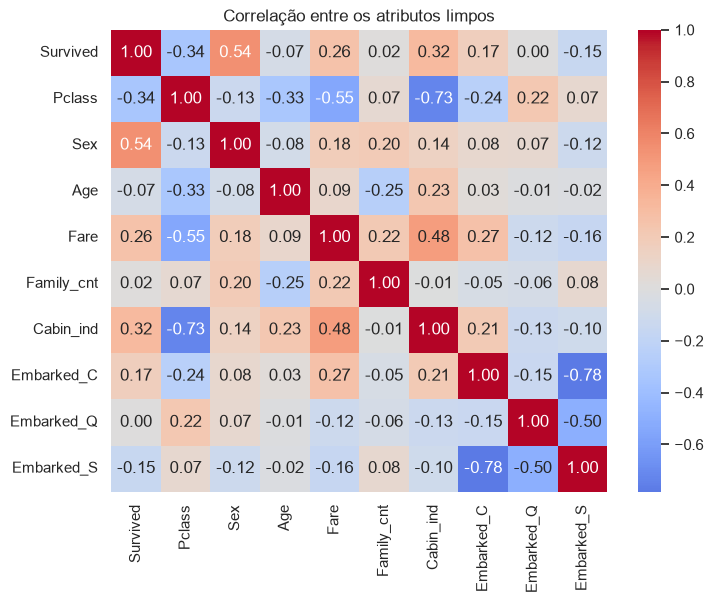

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(titanic.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre os atributos limpos')
plt.show()

`Sex`, `Pclass` e `Cabin_ind` têm as correlações mais fortes com `Survived`, seguidos por `Fare` e `Embarked_C` — tudo consistente com o que vimos nos gráficos bivariados anteriormente. Nenhum dos atributos está tão correlacionado entre si a ponto de nos preocuparmos com redundância, então vamos mantê-los todos para a modelagem.

### Salvar os dados limpos

Salvar o dataset limpo e totalmente numérico em seu próprio CSV significa que notebooks futuros (engenharia de atributos, treinamento de modelo) podem partir dessa base limpa em vez de repetir todas essas etapas.

In [32]:
titanic.to_csv('titanic_cleaned.csv', index=False)

In [33]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Family_cnt  891 non-null    int64  
 6   Cabin_ind   891 non-null    int64  
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


## Resumo

Partindo da lista bruta de passageiros do Titanic, nós:

- Inspecionamos o cabeçalho e o delimitador do arquivo bruto, e verificamos linhas duplicadas e rótulos de categoria inconsistentes
- Comparamos média, mediana e moda para decidir como preencher os valores ausentes de `Age`
- Combinamos `SibSp` e `Parch` em um único atributo `Family_cnt`
- Substituímos o campo `Cabin`, majoritariamente ausente, por um indicador `Cabin_ind`
- Preenchemos os dois valores ausentes de `Embarked` com a moda, e depois aplicamos one-hot encoding, gerando `Embarked_C` / `Embarked_Q` / `Embarked_S`
- Convertemos `Sex` em um campo numérico com um mapeamento manual 0/1
- Visualizamos a sobrevivência de forma bivariada (por `Sex`, `Pclass`, `Age`, `Embarked`) e multivariada (`Age` e `Fare` por sobrevivência, `Pclass` combinado com `Sex`), e confirmamos a história com um mapa de calor de correlação
- Descartamos `PassengerId`, `Name`, `Ticket` e `Cabin`

O resultado é `titanic_cleaned.csv`: uma tabela totalmente numérica e sem valores ausentes, contendo `Survived`, `Pclass`, `Sex`, `Age`, `Fare`, `Family_cnt`, `Cabin_ind`, `Embarked_C`, `Embarked_Q` e `Embarked_S`. A partir daqui, o próximo notebook desta série pode seguir para engenharia de atributos e treinamento de modelo.